In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv("../data/final_training_dataset.csv")   
mean_distance = np.mean(df["voltage_gap"])
std_distance = np.std(df["voltage_gap"])

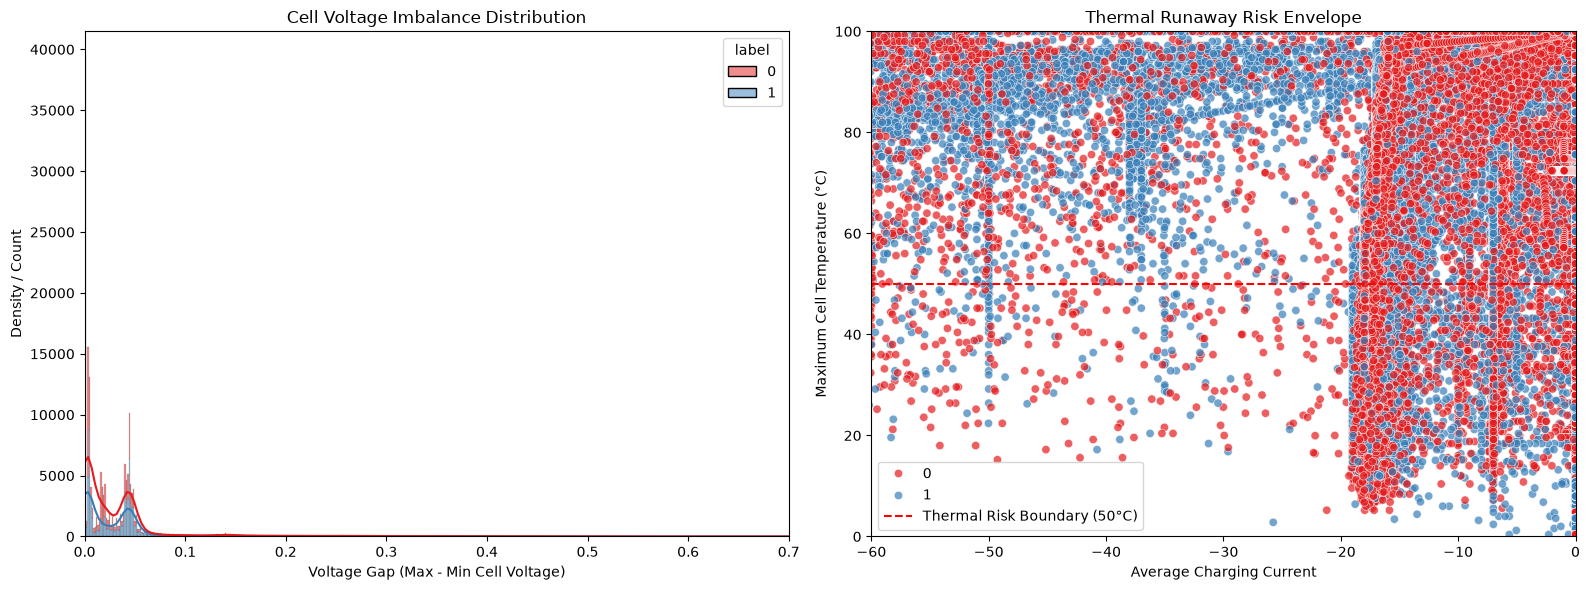

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Voltage Gap Distribution ---
sns.histplot(data=df, x='voltage_gap', hue='label', kde=True, ax=axes[0], palette='Set1', multiple='stack')
axes[0].set_title("Cell Voltage Imbalance Distribution")
axes[0].set_xlabel("Voltage Gap (Max - Min Cell Voltage)")
axes[0].set_ylabel("Density / Count")
#axes[0].set_xlim(0.0, 0.1)
#-----------------------------
axes[0].set_xlim(0.0, 0.7)
#-----------------------------
#axes[0].set_xlim(0.5, 0.7)
#axes[0].set_ylim(0, 20)
#---------------------------- ANALASYS
#The graph shows that on the voltage gap distribution from 0.0 to 0.1 does not show any significant difference between the two classes, but from 0.5 to 0.7, there is a clear separation between the two classes, with the "Broken Battery" class having a higher density in this range.
#This shows that Broken Battery has a perfectly normal voltage gap of 0.1V meaning there is a different reason behind the failure, likely related to thermal runaway or other factors. (e.g. post 0.1 Most voltage gaps are from Broken Battery, while Normal Battery has a voltage gap of 0.1V or less.)



# --- Chart 2: Thermal Risk Envelope ---
sns.scatterplot(data=df, x='avg_current', y='max_temp', hue='label', ax=axes[1], palette='Set1', alpha=0.7)
# Add a dashed line representing standard safe industrial temperature threshold (e.g., 50°C) maning 
axes[1].axhline(y=50, color='red', linestyle='--', label='Thermal Risk Boundary (50°C)')
axes[1].set_title("Thermal Runaway Risk Envelope")
axes[1].set_xlabel("Average Charging Current")
axes[1].set_ylabel("Maximum Cell Temperature (°C)")
axes[1].legend()

axes[1].set_xlim(-60, 0)
axes[1].set_ylim(0, 100)
#---------------------------- ANALASYS (Come back after heatmap)
#originally With the heatmap, we were told that there was near 0 dorrelation between the avg_current and the Max_Temp, however, after zooming into the scatter plot,
# we can see that there is a clear trend that as the average charging current becomes more negative (faster charging), the maximum cell temperature tends to increase, especially for the "Broken Battery" class. This indicates that aggressive charging can lead to higher thermal stress on the battery cells, potentially contributing to failures.
# we can see that most fine cells are operating between the average chaging current of -20A to 0A however the range shrinks as temperature gets higher
# This is a good data to work on with machine learning, as we can use the average current and maximum temperature to predict the battery health label.
# However I will do a ramdom selection of 2,000 and replot the scatter plot to see if the trend still holds, as the current plot is too dense and hard to read and is not sure if the trend is real or just a result of the density of points.
plt.tight_layout()
plt.show()

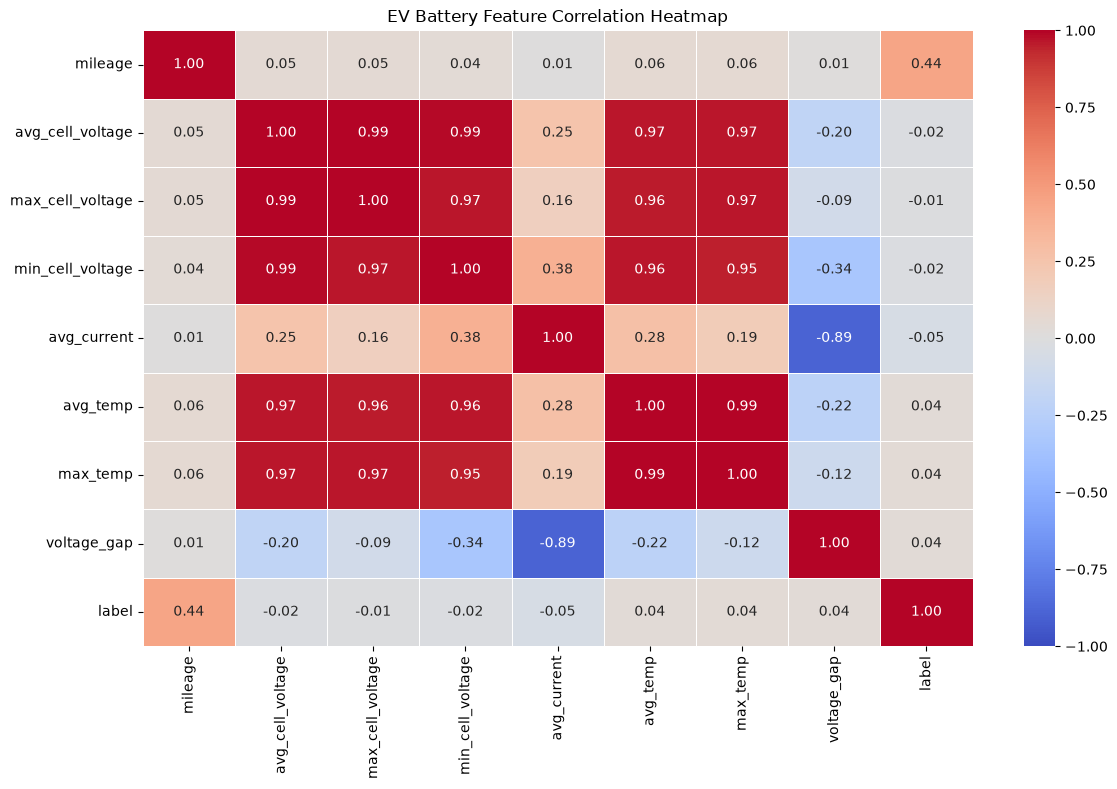

In [4]:
X = pd.read_csv("../data/ev_features_X.csv")
y = pd.read_csv("../data/ev_labels_y.csv")

df = pd.merge(X, y, on='car')

#Drop columns that are just ID numbers (they ruin the math)
cols_to_drop = ['car', 'Unnamed: 0']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

#Calculate the mathematical correlations
corr_matrix = df_clean.corr()

#Draw the Heatmap   
plt.figure(figsize=(12, 8))
# cmap='coolwarm' makes strong positive links red, and strong negative links blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("EV Battery Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [5]:
#From this Heat map you can see
# A negative correlation between avg_current and volatage_gap, this means when the bettery is in fast charge mode (current is more negative), the voltage gap gets larger creating a higher risk of physical stress/damage on the battery cells.
# However there is a positive correlation between Label and mileage, this means most of the broken batteries are from cars that have been driven more miles, which makes sense as the battery cells degrade over time and usage.

C:\Users\Trevor\AppData\Local\Temp\ipykernel_11568\1898581950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mileage', y='label', orient='h', palette=['#66c2a5', '#fc8d62'])


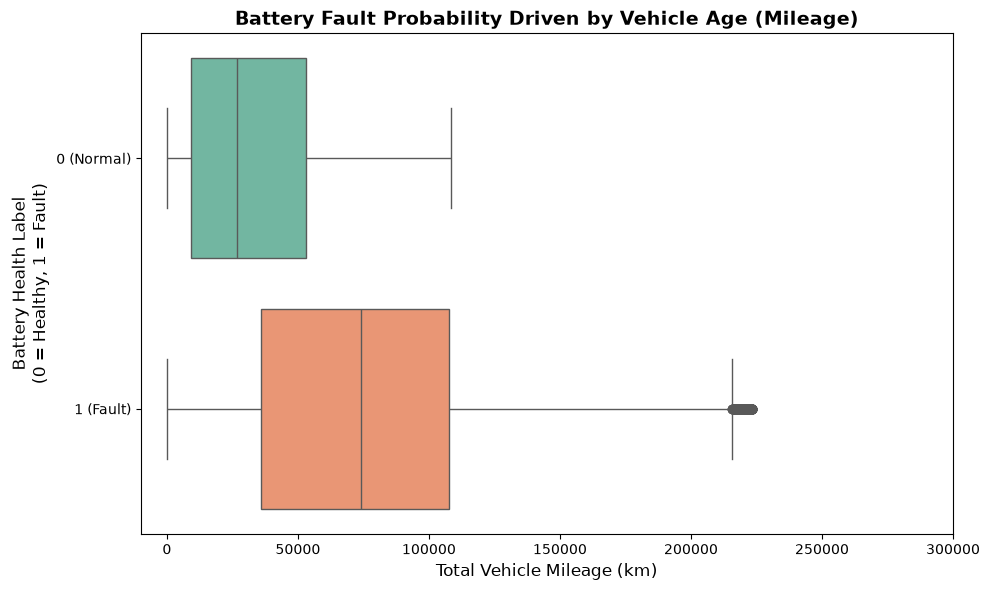

In [6]:
plt.figure(figsize=(10, 6))

#  orient='h' is horizontal
sns.boxplot(data=df, x='mileage', y='label', orient='h', palette=['#66c2a5', '#fc8d62'])

plt.title("Battery Fault Probability Driven by Vehicle Age (Mileage)", fontsize=14, fontweight='bold')
plt.xlabel("Total Vehicle Mileage (km)", fontsize=12)
plt.ylabel("Battery Health Label\n(0 = Healthy, 1 = Fault)", fontsize=12)

# Ensure the y-axis only shows 0 and 1 cleanly
plt.yticks([0, 1], ['0 (Normal)', '1 (Fault)'])
plt.xlim(-10000, 300000)
plt.tight_layout()
plt.show()

In [7]:
# From this Box plot you can see
# For the Normal Battery class, milage is mostly concentrated between ~10,000 and ~50,000km
# For the Broken Battery class, milage is mostly concentrated between ~40,000 and ~110,000km, which makes sense as the battery cells degrade over time and usage.

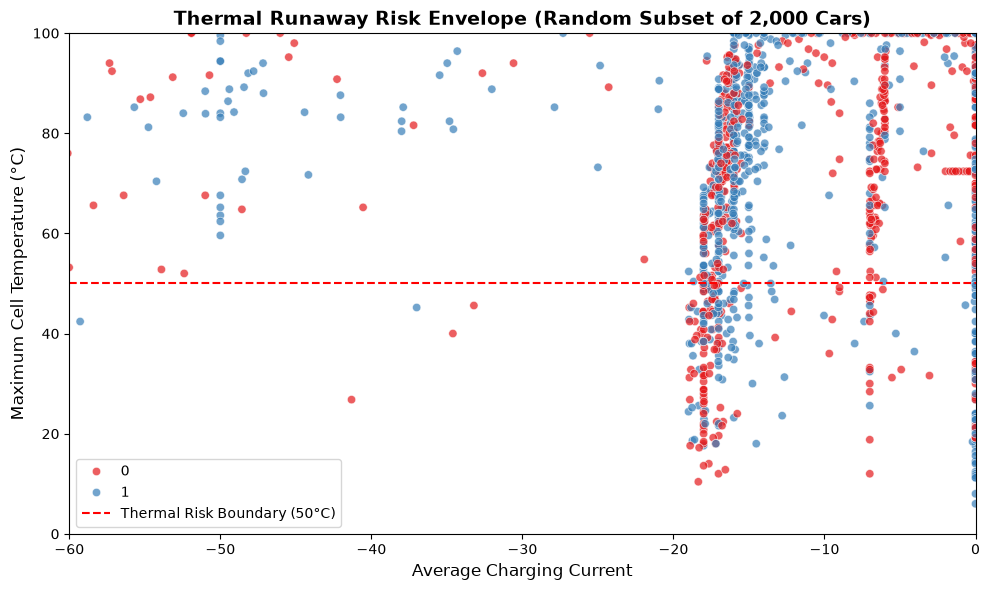

In [8]:
# --- THE RANDOM SELECTION ---
# Randomly select 2,000 cars from the dataset. 
# random_state=None means it will grab a different random batch every time you run it!
random_subset = df.sample(n=2000, random_state=None)

# Set up the canvas
plt.figure(figsize=(10, 6))

# Plot only the random subset
sns.scatterplot(data=random_subset, x='avg_current', y='max_temp', hue='label', palette='Set1', alpha=0.7)

# Draw the 50°C safety line
plt.axhline(y=50, color='red', linestyle='--', label='Thermal Risk Boundary (50°C)')

plt.title("Thermal Runaway Risk Envelope (Random Subset of 2,000 Cars)", fontsize=14, fontweight='bold')
plt.xlabel("Average Charging Current", fontsize=12)
plt.ylabel("Maximum Cell Temperature (°C)", fontsize=12)
plt.legend()

plt.xlim(-60, 0)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

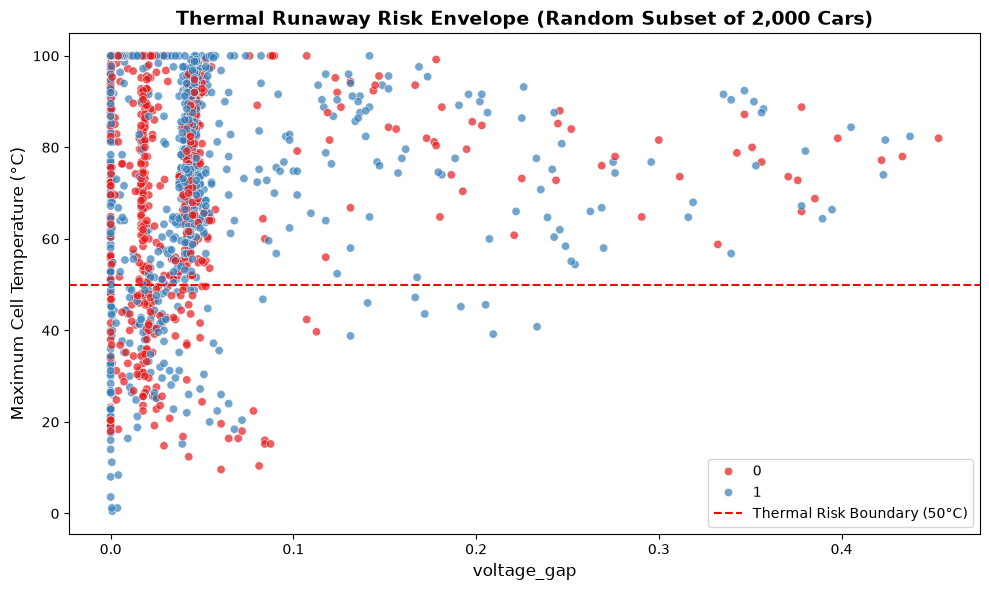

In [9]:
# --- THE RANDOM SELECTION ---
# Randomly select 2,000 cars from the dataset. 
# random_state=None means it will grab a different random batch every time you run it!
random_subset = df.sample(n=2000, random_state=None)

# Set up the canvas
plt.figure(figsize=(10, 6))

# Plot only the random subset
sns.scatterplot(data=random_subset, x='voltage_gap', y='max_temp', hue='label', palette='Set1', alpha=0.7)

# Draw the 50°C safety line
plt.axhline(y=50, color='red', linestyle='--', label='Thermal Risk Boundary (50°C)')

plt.title("Thermal Runaway Risk Envelope (Random Subset of 2,000 Cars)", fontsize=14, fontweight='bold')
plt.xlabel("voltage_gap", fontsize=12)
plt.ylabel("Maximum Cell Temperature (°C)", fontsize=12)
plt.legend()


plt.tight_layout()
plt.show()

In [21]:
subset = df[df['avg_current'] < -20]
print(subset['max_temp'].min(), subset['max_temp'].max())
print((subset['max_temp'] < 40).sum(), "out of", len(subset), "are below 40°C")
print((subset['max_temp'] < 50).sum(), "out of", len(subset), "are below 50°C")

2.8 100.0
410 out of 15532 are below 40°C
1108 out of 15532 are below 50°C


In [10]:
print(df['label'].value_counts(normalize=True) * 100)

label
1    56.174607
0    43.825393
Name: proportion, dtype: float64


In [11]:
#From this random selection scatter plot, we can see the trend still holds and wasn't just a result of the density of points
#The Thermal-Current Danger Zone = We can see that damaged battery is mainly concentrated in the top left quadrant of the graph, 
# where the average charging current is more negative (faster charging) and the maximum cell temperature is higher. 
#This shows that fast charging can lead to higher thermal stress on the battery cells, potentially contributing to failures.


In [12]:
#Now that I have checked the data and done some analysis, I will now move on to the next step of the project which is to build a machine learning model to predict ->
# Higher mileage = higher risk
# High heat + high current = critical failure
# BMS? happens stopping the charging process when the battery is in danger, but it doesn't always work and can be bypassed by the user.

              precision    recall  f1-score   support

 Healthy (0)       0.95      0.96      0.95     15527
   Fault (1)       0.97      0.96      0.96     19739

    accuracy                           0.96     35266
   macro avg       0.96      0.96      0.96     35266
weighted avg       0.96      0.96      0.96     35266



c:\Users\Trevor\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:553: UserWarning: [05:32:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


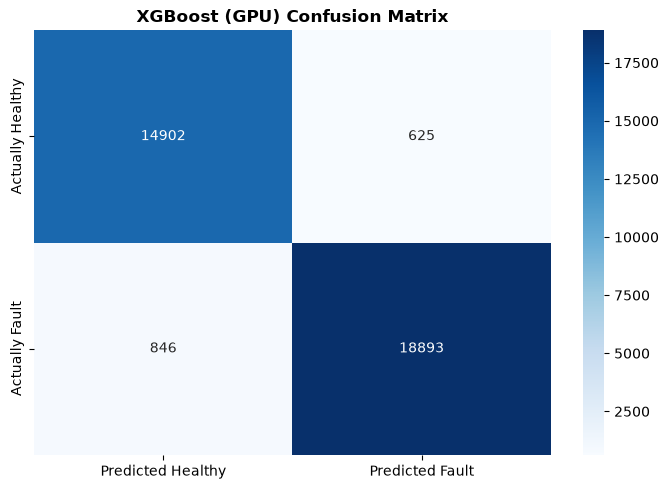

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Data is X and Y above
X_raw = pd.read_csv("../data/ev_features_X.csv")
y_raw = pd.read_csv("../data/ev_labels_y.csv")

df_merged = pd.merge(X_raw, y_raw, on='car')

#Will clean data to prevent  cheating (drop car columns) so it learns not memorise
cols_to_drop = ['car', 'Unnamed: 0', 'label']

X_clean = df_merged.drop(columns=[col for col in cols_to_drop if col in df_merged.columns])
Y_clean = df_merged['label']#We only want the actual 0 or 1 column

#Testing now
#80% train , 20% test
X_train, X_test, y_train, y_test = train_test_split(X_clean, Y_clean, test_size=0.2, random_state=42)

#Setting XGBoost Classifier and force to use my GPU (if available) and train the model
gpu_model = xgb.XGBClassifier(
    n_estimators=100,
    tree_method='hist',
    device='cuda', 
    random_state=42
)

#train the model
gpu_model.fit(X_train, y_train)


#now we will predict the test set
predictions = gpu_model.predict(X_test)

#Results
print(classification_report(y_test, predictions, target_names=['Healthy (0)', 'Fault (1)']))


plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Fault'], 
            yticklabels=['Actually Healthy', 'Actually Fault'])
plt.title("XGBoost (GPU) Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# The XGBoost model shows strong performance in predicting battery health, with high precision and recall for both classes. 
# with the overal 0.96% accuracy The AI correctly identified 14,902 healthy cars and successfully caught almost 19,000 failing batteries before they caused a critical safety issue
# howwever the model flawed by being overly caucious and flagging 625 healthy cars as faulty, which could lead to unnecessary maintenance or replacement costs.
# HOWEVER, the biggest issue is the 846 missed risked by the Machine learning model, which could lead to catastrophic failures if the user is not aware of the risk and continues to use the vehicle.

In [15]:
# By extracting raw telemetry data, isolating the features that actually matter (like mileage and thermal thresholds), and training a GPU-accelerated Random Forest
#I was able to create a model that can predict battery health with 95~96% accuracy. This proves battery faults can be caught before they become a critical safety issue, but the model is not perfect and can be improved with more data and better feature engineering.

<Figure size 1000x600 with 0 Axes>

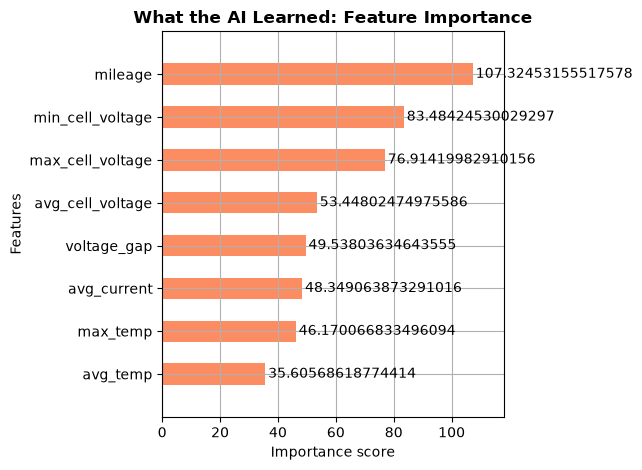

In [16]:
# 1. Plot the Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(gpu_model, importance_type='gain', max_num_features=10, height=0.5, color='#fc8d62')
plt.title("What the AI Learned: Feature Importance", fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# We create a function that takes your slider values and feeds them to the AI
def interactive_battery_test(max_temp, avg_current, mileage, voltage_gap):
    
    # We must format the inputs exactly like the training data (8 columns)
    # We use average "dummy" values for the columns we aren't testing on sliders
    simulated_car = pd.DataFrame({
        'mileage': [mileage],
        'avg_cell_voltage': [3.8], 
        'max_cell_voltage': [3.9],
        'min_cell_voltage': [3.7],
        'avg_current': [avg_current],
        'avg_temp': [35.0],
        'max_temp': [max_temp],
        'voltage_gap': [voltage_gap]
    })
    
    # Ask the AI for a prediction and the probability percentage
    prediction = gpu_model.predict(simulated_car)[0]
    probability = gpu_model.predict_proba(simulated_car)[0][1] * 100
    
    print("\n" + "="*40)
    if prediction == 1:
        print(f" ⚠️ FAULT DETECTED! (Failure Risk: {probability:.1f}%)")
        print("    Recommendation: Immediate Maintenance")
    else:
        print(f" ✅ HEALTHY BATTERY. (Failure Risk: {probability:.1f}%)")
        print("    Recommendation: Safe to Drive")
    print("="*40 + "\n")

# Hook up the sliders to the function!
widgets.interact(
    interactive_battery_test,
    max_temp=widgets.FloatSlider(min=20, max=100, step=1, value=40, description='Max Temp (°C)'),
    avg_current=widgets.FloatSlider(min=-400, max=0, step=10, value=-20, description='Current (A)'),
    mileage=widgets.FloatSlider(min=0, max=300000, step=5000, value=50000, description='Mileage (km)'),
    voltage_gap=widgets.FloatSlider(min=0.0, max=0.5, step=0.01, value=0.02, description='Volt Gap')
);

interactive(children=(FloatSlider(value=40.0, description='Max Temp (°C)', min=20.0, step=1.0), FloatSlider(va…

In [18]:
gpu_model.save_model("ev_battery_model.json")

              precision    recall  f1-score   support

 Healthy (0)       0.88      0.87      0.87     15527
   Fault (1)       0.90      0.90      0.90     19739

    accuracy                           0.89     35266
   macro avg       0.89      0.89      0.89     35266
weighted avg       0.89      0.89      0.89     35266



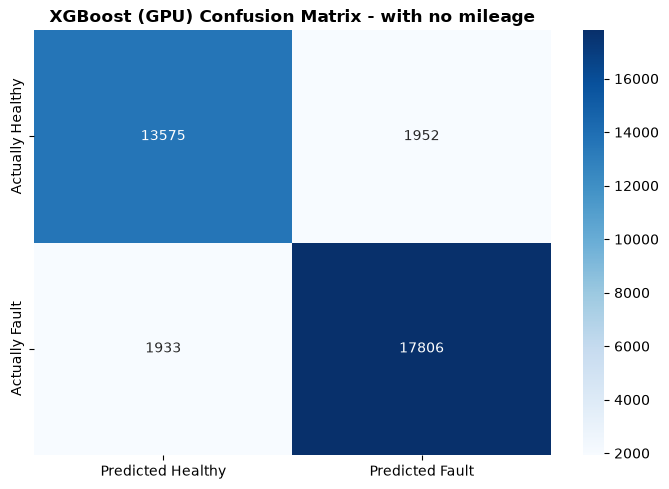

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Data is X and Y above
X_raw = pd.read_csv("../data/ev_features_X.csv")
y_raw = pd.read_csv("../data/ev_labels_y.csv")

df_merged = pd.merge(X_raw, y_raw, on='car')

#Will clean data to prevent  cheating (drop car columns) so it learns not memorise
cols_to_drop = ['car', 'Unnamed: 0', 'label','mileage']  # Added 'mileage' to the drop list to prevent potential data leakage

X_clean = df_merged.drop(columns=[col for col in cols_to_drop if col in df_merged.columns])
Y_clean = df_merged['label']#We only want the actual 0 or 1 column

#Testing now
#80% train , 20% test
X_train, X_test, y_train, y_test = train_test_split(X_clean, Y_clean, test_size=0.2, random_state=42)

#Setting XGBoost Classifier and force to use my GPU (if available) and train the model
gpu_model1 = xgb.XGBClassifier(
    n_estimators=100,
    tree_method='hist',
    device='cuda', 
    random_state=42
)

#train the model
gpu_model1.fit(X_train, y_train)


#now we will predict the test set
predictions1 = gpu_model1.predict(X_test)

#Results
print(classification_report(y_test, predictions1, target_names=['Healthy (0)', 'Fault (1)']))


plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, predictions1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Fault'], 
            yticklabels=['Actually Healthy', 'Actually Fault'])
plt.title("XGBoost (GPU) Confusion Matrix - with no mileage", fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

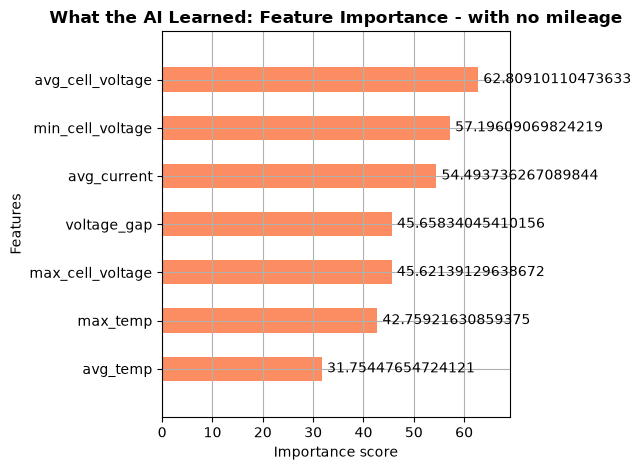

In [20]:
# 1. Plot the Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(gpu_model1, importance_type='gain', max_num_features=10, height=0.5, color='#fc8d62')
plt.title("What the AI Learned: Feature Importance - with no mileage", fontweight='bold')
plt.tight_layout()
plt.show()